# Messy Testing Environment

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, classification_report
from sklearn.calibration import CalibratedClassifierCV

In [17]:
query0126 = pd.read_csv("Queries/New_Query_2026_01_26_12_07pm.csv")
query0126.head()

,hubspot_id,state,viability_score,candidate_office,official_office_name,office_level,office_type,election_date,general_election_result,general_votes_received,...,script,outreach_status,outreach_type,outreach_date,message,phone_list_id,audience_request,voter_file_filter_id,outreach_created_at,outreach_updated_at
0,50389592099,Texas,NaN,Houston City Mayor,NaN,CITY,Mayor,2027-11-02,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,49589731742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,49087205139,Illinois,NaN,Illinois Governor,NaN,STATE,NaN,2026-11-03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,47415135027,California,NaN,Claremont City Council - District 4,NaN,CITY,NaN,2026-11-03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20641508435,Oregon,0.23,Oregon House of Representatives - District 3,NaN,STATE,State Senate,2026-11-03,Not on Ballot,107.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# -----------------------------
# 1) Clean + label
# -----------------------------


def clean_result(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    # normalize common spacing/casing issues if needed
    x = " ".join(x.split())
    return x

def map_is_uncontested(x):
    # tri-state: True/False/NaN
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"true", "t", "yes", "y", "1"}:
        return True
    if s in {"false", "f", "no", "n", "0"}:
        return False
    return np.nan

def build_training_frame(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["general_election_result"] = df["general_election_result"].apply(clean_result)

    # Trainable labels only
    train_mask = df["general_election_result"].isin(["Won General", "Lost General"])
    df_train = df.loc[train_mask].copy()

    df_train["y_win_general"] = (df_train["general_election_result"] == "Won General").astype(int)

    # Parse election_date
    df_train["election_date"] = pd.to_datetime(df_train["election_date"], errors="coerce")
    df_train["election_year"] = df_train["election_date"].dt.year
    df_train["election_month"] = df_train["election_date"].dt.month

    # Booleans
    df_train["is_uncontested_bool"] = df_train["is_uncontested"].apply(map_is_uncontested)

    # Outreach presence flag (since outreach cols are very sparse)
    df_train["has_outreach"] = df_train["outreach_id"].notna().astype(int)

    return df_train

In [19]:
# -----------------------------
# 2) Feature selection
# -----------------------------
def get_feature_columns():
    # Avoid obvious leakage: DO NOT include votes columns or the outcome itself.
    # viability_score: include only if you are sure it is pre-election and not derived from results.
    numeric_features = [
        "viability_score",        # OPTIONAL: remove if leakage risk
        "election_month",
        "has_outreach",
    ]
    categorical_features = [
        "state",
        "candidate_office",
        "official_office_name",
        "office_level",
        "office_type",
        "election_year",
        "is_uncontested_cat",
    ]

    return numeric_features, categorical_features

In [20]:

# -----------------------------
# 3) Train/test split (time-aware if possible)
# -----------------------------

def robust_time_split(df, year_col="election_year", label_col="y_win_general", min_test=200):
    df = df.copy()
    df = df[df[year_col].notna()].copy()

    # count labeled rows per year
    year_counts = df.groupby(year_col)[label_col].size().sort_index()
    # choose latest year meeting min_test
    eligible_years = year_counts[year_counts >= min_test]
    
    if len(eligible_years) >= 1:
        test_year = eligible_years.index.max()
        train_df = df[df[year_col] < test_year].copy()
        test_df  = df[df[year_col] == test_year].copy()
        note = f"time_split_holdout_year={test_year} (n_test={len(test_df)})"
        return train_df, test_df, note
    
    # fallback: last X% of time as test, if you still want time-awareness
    # otherwise: stratified random
    from sklearn.model_selection import train_test_split
    train_df, test_df = train_test_split(
        df, test_size=0.2, random_state=42, stratify=df[label_col]
    )
    note = f"fallback_random_split_80_20 (n_test={len(test_df)})"
    return train_df, test_df, note

    

    

In [21]:
# -----------------------------
# 4) Modeling pipeline + calibration
# -----------------------------

def build_model_pipeline(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop"
    )

    base_clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",  # safe default
        solver="lbfgs"
    )

    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", base_clf)
    ])

    return model

def evaluate(model, X_test, y_test, label="model"):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    print(f"\n=== {label} ===")
    print("ROC-AUC:", roc_auc_score(y_test, proba))
    print("PR-AUC:", average_precision_score(y_test, proba))
    print("Brier:", brier_score_loss(y_test, proba))
    print("\nClassification report (threshold=0.5):")
    print(classification_report(y_test, pred, digits=3))

In [22]:
# -----------------------------
# 5) Run everything
# -----------------------------


df_train = build_training_frame(query0126)

df_train["is_uncontested_cat"] = (
    df_train["is_uncontested"]
      .astype("string")
      .str.strip()
      .str.lower()
      .replace({"": pd.NA})
      .where(lambda s: s.isin(["contested", "uncontested"]), other=pd.NA)
      .fillna("unknown")
)

# OPTIONAL: if you suspect viability_score leaks, drop it here:
# df_train["viability_score"] = np.nan  # or remove from numeric_features below

numeric_features, categorical_features = get_feature_columns()

# Drop rows with missing election_date if you rely on time split; otherwise you can keep them.
# df_train = df_train[df_train["election_year"].notna()].copy()

train_df, test_df, split_note = robust_time_split(df_train, min_test=200)
print("Split:", split_note, "| Train:", len(train_df), "| Test:", len(test_df))


X_train = train_df[numeric_features + categorical_features]
y_train = train_df["y_win_general"].values

X_test = test_df[numeric_features + categorical_features]
y_test = test_df["y_win_general"].values

model = build_model_pipeline(numeric_features, categorical_features)
model.fit(X_train, y_train)
evaluate(model, X_test, y_test, label="LogReg (uncalibrated)")

# Probability calibration (improves interpretability of "p_win")
calibrated = CalibratedClassifierCV(model, method="isotonic", cv=3)
calibrated.fit(X_train, y_train)
evaluate(calibrated, X_test, y_test, label="LogReg (calibrated, isotonic)")

Split: time_split_holdout_year=2025.0 (n_test=2723) | Train: 1106 | Test: 2723

=== LogReg (uncalibrated) ===
ROC-AUC: 0.7160667974259025
PR-AUC: 0.8071871211527079
Brier: 0.23308636407956196

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0      0.528     0.790     0.633      1087
           1      0.792     0.531     0.635      1636

    accuracy                          0.634      2723
   macro avg      0.660     0.660     0.634      2723
weighted avg      0.687     0.634     0.634      2723


=== LogReg (calibrated, isotonic) ===
ROC-AUC: 0.713423871358104
PR-AUC: 0.8020726235831712
Brier: 0.2269287659848534

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0      0.540     0.682     0.603      1087
           1      0.744     0.615     0.673      1636

    accuracy                          0.642      2723
   macro avg      0.642     0.648     0.638      2723
weighted a

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def get_pred_df(fit_model, X, y):
    proba = fit_model.predict_proba(X)[:, 1]
    return pd.DataFrame({"y": np.asarray(y).astype(int), "p": proba})

# Choose which model to evaluate:
eval_model = calibrated  # or model

pred = get_pred_df(eval_model, X_test, y_test)
pred.head()


,y,p
0,0,0.219864
1,1,0.936543
2,1,0.319165
3,0,0.312852
4,0,0.096737


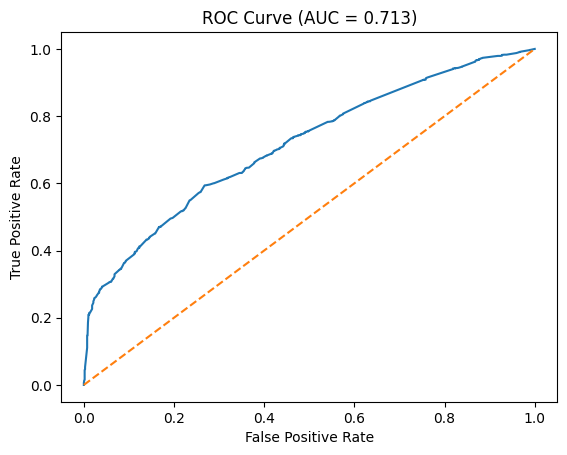

In [25]:
fpr, tpr, _ = roc_curve(pred["y"], pred["p"])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.show()


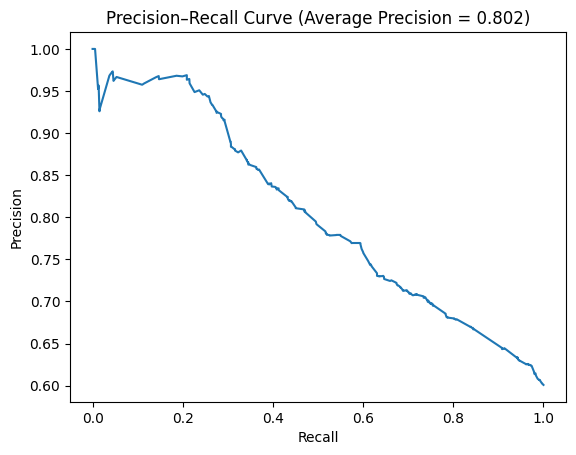

In [26]:
precision, recall, _ = precision_recall_curve(pred["y"], pred["p"])
ap = average_precision_score(pred["y"], pred["p"])

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (Average Precision = {ap:.3f})")
plt.show()


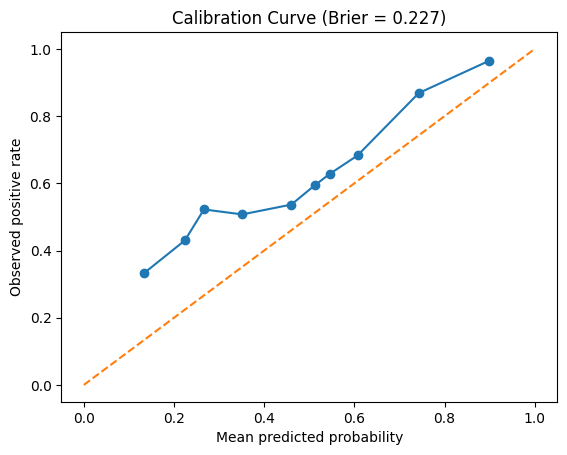

In [27]:
prob_true, prob_pred = calibration_curve(pred["y"], pred["p"], n_bins=10, strategy="quantile")
brier = brier_score_loss(pred["y"], pred["p"])

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title(f"Calibration Curve (Brier = {brier:.3f})")
plt.show()


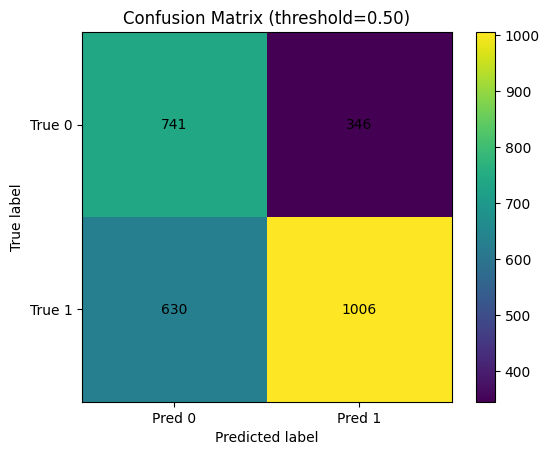

In [28]:
def plot_confusion_at_threshold(pred_df, threshold=0.5):
    y_true = pred_df["y"].values
    y_hat = (pred_df["p"].values >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])

    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix (threshold={threshold:.2f})")
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["True 0", "True 1"])
    plt.colorbar()

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

plot_confusion_at_threshold(pred, threshold=0.5)


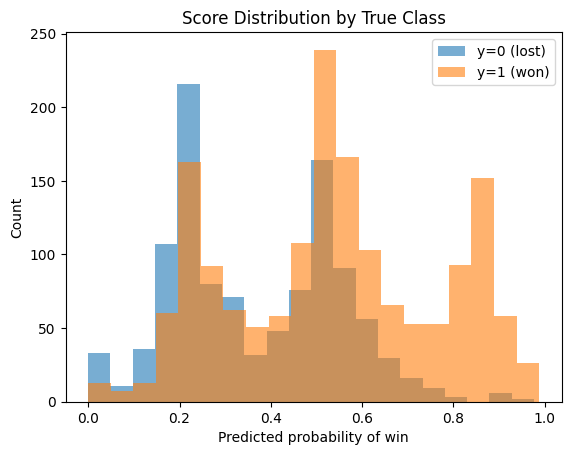

In [29]:
plt.figure()
plt.hist(pred.loc[pred["y"] == 0, "p"], bins=20, alpha=0.6, label="y=0 (lost)")
plt.hist(pred.loc[pred["y"] == 1, "p"], bins=20, alpha=0.6, label="y=1 (won)")
plt.xlabel("Predicted probability of win")
plt.ylabel("Count")
plt.title("Score Distribution by True Class")
plt.legend()
plt.show()


In [30]:
def decile_table(pred_df, n_bins=10):
    df = pred_df.copy()
    # qcut can fail with too few rows / duplicates; handle gracefully
    try:
        df["bin"] = pd.qcut(df["p"], q=n_bins, duplicates="drop")
    except ValueError:
        # fallback: fewer bins
        df["bin"] = pd.qcut(df["p"], q=min(5, len(df)), duplicates="drop")

    out = (
        df.groupby("bin")
          .agg(
              n=("y", "size"),
              avg_pred=("p", "mean"),
              win_rate=("y", "mean"),
          )
          .reset_index()
          .sort_values("avg_pred", ascending=False)
    )

    overall = df["y"].mean()
    out["lift_vs_overall"] = out["win_rate"] / overall if overall > 0 else np.nan
    return out, overall

deciles, overall_rate = decile_table(pred, n_bins=10)
print("Overall win rate:", round(overall_rate, 3))
deciles


Overall win rate: 0.601


/var/folders/4v/55nqzrk56yz5gzf4ld7y124h0000gn/T/ipykernel_25086/2135519215.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("bin")


,bin,n,avg_pred,win_rate,lift_vs_overall
9,"(0.799, 0.988]",250,0.897680,0.964000,1.604506
8,"(0.644, 0.799]",274,0.742837,0.868613,1.445742
7,"(0.566, 0.644]",287,0.606978,0.682927,1.136681
6,"(0.527, 0.566]",275,0.546584,0.629091,1.047075
5,"(0.494, 0.527]",271,0.512041,0.594096,0.988828
4,"(0.415, 0.494]",272,0.460349,0.536765,0.893405
3,"(0.282, 0.415]",266,0.351341,0.507519,0.844727
2,"(0.228, 0.282]",180,0.266369,0.522222,0.869200
1,"(0.187, 0.228]",372,0.224162,0.430108,0.715882
0,"(-0.001, 0.187]",276,0.134168,0.333333,0.554808


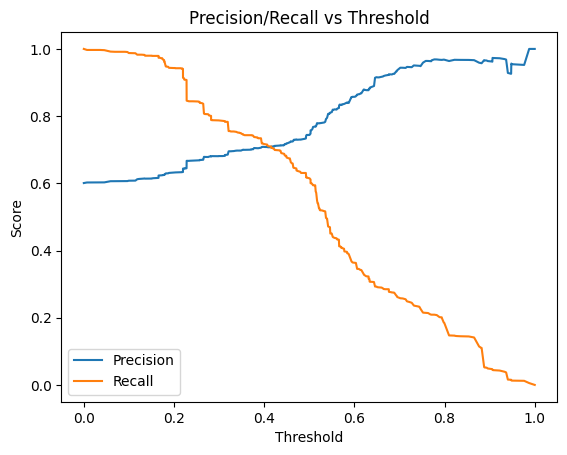

In [31]:
precision, recall, thresholds = precision_recall_curve(pred["y"], pred["p"])

# thresholds is length-1 compared to precision/recall
thr = np.r_[thresholds, 1.0]

plt.figure()
plt.plot(thr, precision, label="Precision")
plt.plot(thr, recall, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall vs Threshold")
plt.legend()
plt.show()
